# Aula 9 — Regressão Linear e Mínimos Quadrados
### Formulação matricial, interpretação geométrica, equações normais, pseudoinversa e ajuste polinomial

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 9 e abre o Módulo 2. A regressão linear resolve
$A\boldsymbol\beta\approx\mathbf{b}$ quando há mais equações do que incógnitas: escolhemos
$\boldsymbol\beta$ que minimiza $\|A\boldsymbol\beta-\mathbf{b}\|_2^2$. Vamos ver as três leituras
equivalentes — **minimização**, **projeção ortogonal** em $\operatorname{Col}(A)$ e solução por
**equações normais** ou **pseudoinversa/SVD** — e comparar os métodos numericamente.

"Linear" refere-se aos **parâmetros**: um ajuste polinomial $y\approx\beta_0+\beta_1x+\cdots$ é
regressão linear, embora seja não linear em $x$.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | equações normais, `lstsq`, `pinv`, SVD, condicionamento |
| `matplotlib` | 3.5 | dados, ajustes, resíduos |
| `scikit-learn` | 1.0 | `LinearRegression` (comparação de métodos) |

```bash
pip install numpy matplotlib scikit-learn
```

> A regressão principal é feita com **numpy**. A comparação usa `scikit-learn`, importado
> diretamente e listado nos Requisitos.

In [1]:
# --- Imports concentrados ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Há dados aleatórios mais adiante (np.random.randn). Fixamos a semente para que
# os números (e os gráficos) sejam sempre os mesmos a cada execução.
np.random.seed(42)


# As "equações normais" A^T A beta = A^T b são o coração da aula: resolvê-las
# DÁ a solução de mínimos quadrados. Por isso escrevemos esta etapa à mão, em vez
# de chamar um solver de regressão pronto — queremos ver a conta acontecendo.
# A^T A é a matriz dos produtos internos entre as colunas de A; A^T b é o lado direito.
# np.linalg.solve(M, c) resolve o sistema linear M @ beta = c de forma estável
# (NÃO invertemos a matriz explicitamente, que seria mais caro e menos preciso).
def ajuste_normais(A, b):
    '''Mínimos quadrados pelas equações normais A^T A beta = A^T b.'''
    return np.linalg.solve(A.T @ A, A.T @ b)


print("Ambiente pronto.")

Ambiente pronto.


## Objetivos computacionais

1. Resolver mínimos quadrados pelas **equações normais** $A^TA\widehat{\boldsymbol\beta}=A^T\mathbf{b}$.
2. Verificar a **geometria**: resíduo ortogonal $A^T\mathbf{e}=0$.
3. Reproduzir os Exemplos 1 (reta) e 2 (quadrática) das notas.
4. Resolver via **pseudoinversa/SVD** e **comparar métodos**.
5. Discutir **condicionamento** ($\kappa(A^TA)=\kappa(A)^2$), ajuste **ponderado** e **lei de potência**.

## 1. Ajuste de reta pelas equações normais (Exemplo 1)

Pontos $(0,1),(1,2),(2,2),(3,4)$. Espera-se $\widehat{\boldsymbol\beta}=(9/10,9/10)$.

A^T A =
 [[ 4.  6.]
 [ 6. 14.]] 
A^T b = [ 9. 18.]
beta = [0.9 0.9] (esperado 0.9, 0.9)


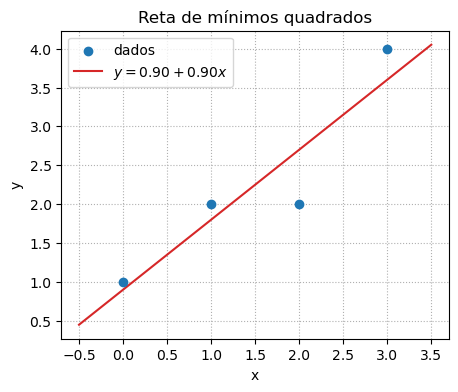

In [2]:
# Exemplo 1: ajustar a reta y = b0 + b1*x aos quatro pontos das notas.
x = np.array([0.0, 1.0, 2.0, 3.0])     # valores de x dos pontos medidos
b = np.array([1.0, 2.0, 2.0, 4.0])     # valores de y (o vetor de dados das notas)

# Matriz de projeto A: cada linha é [1, x_i], pois o modelo é b0*1 + b1*x.
# np.ones_like(x) cria um vetor de 1's do mesmo tamanho de x (a coluna do termo constante b0).
# np.column_stack empilha esses dois vetores LADO A LADO, como colunas -> matriz 4x2.
A = np.column_stack([np.ones_like(x), x])      # colunas [1, x]

# Montamos e mostramos as duas peças das equações normais e depois resolvemos.
print("A^T A =\n", A.T @ A, "\nA^T b =", A.T @ b)
beta = ajuste_normais(A, b)                    # resolve A^T A beta = A^T b
print("beta =", beta, "(esperado 0.9, 0.9)")

# Gráfico: os pontos (dados) e a reta ajustada.
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, b, color="tab:blue", zorder=3, label="dados")   # zorder=3 deixa os pontos por cima

# Para desenhar a reta, criamos muitos x's finos no intervalo e avaliamos b0 + b1*x em cada um.
xx = np.linspace(-0.5, 3.5, 100)
ax.plot(xx, beta[0] + beta[1] * xx, "tab:red",
        label=f"$y={beta[0]:.2f}+{beta[1]:.2f}x$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, ls=":")
ax.set_title("Reta de mínimos quadrados")
plt.show()

## 2. Geometria: o resíduo é ortogonal a $\operatorname{Col}(A)$

A condição de ótimo é $A^T\mathbf{e}=0$ com $\mathbf{e}=\mathbf{b}-A\widehat{\boldsymbol\beta}$:
nenhuma mudança em $\boldsymbol\beta$ reduz mais o erro.

resíduo e = [ 0.1  0.2 -0.7  0.4]
A^T e = [0. 0.] (deve ser ~0)


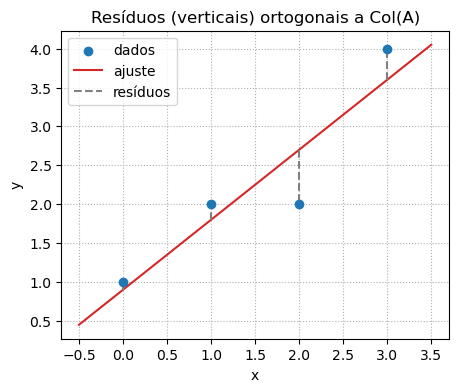

In [3]:
# Resíduo e ortogonalidade.
# O resíduo é a diferença entre os dados e o que a reta prevê: e = b - A@beta.
e = b - A @ beta
print("resíduo e =", np.round(e, 4))

# Condição de ótimo de mínimos quadrados: o resíduo é ortogonal às colunas de A,
# ou seja, A^T e = 0. Arredondamos em 12 casas só para esconder o "lixo numérico".
print("A^T e =", np.round(A.T @ e, 12), "(deve ser ~0)")

# Gráfico: dados, reta ajustada e os resíduos como segmentos verticais.
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, b, color="tab:blue", zorder=3, label="dados")
ax.plot(xx, beta[0] + beta[1] * xx, "tab:red", label="ajuste")

# ax.vlines(x, y_baixo, y_alto) desenha um segmento vertical em cada x.
# Aqui ligamos o valor PREVISTO pela reta (beta0 + beta1*x) ao valor MEDIDO (b):
# o comprimento de cada segmento é exatamente o resíduo daquele ponto.
ax.vlines(x, beta[0] + beta[1] * x, b, color="gray", ls="--", label="resíduos")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, ls=":")
ax.set_title("Resíduos (verticais) ortogonais a Col(A)")
plt.show()

## 3. Ajuste quadrático (Exemplo 2)

Mesmos dados, modelo $y\approx\beta_0+\beta_1x+\beta_2x^2$. Espera-se
$\widehat{\boldsymbol\beta}=(23/20,3/20,1/4)=(1.15,0.15,0.25)$.

beta (quadrático) = [1.15 0.15 0.25] (esperado 1.15, 0.15, 0.25)
A^T e = [-0. -0.  0.]


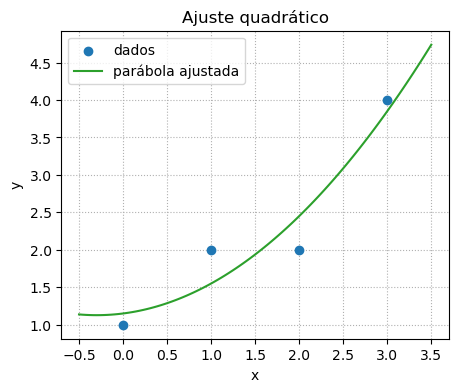

In [4]:
# Exemplo 2: mesmo procedimento, agora com modelo quadrático y = b0 + b1*x + b2*x^2.
# A matriz de projeto ganha uma terceira coluna, x^2. Como temos as colunas
# [1, x, x^2], ela é uma matriz de Vandermonde (potências crescentes de x).
A2 = np.column_stack([np.ones_like(x), x, x**2])   # colunas [1, x, x^2]
beta2 = ajuste_normais(A2, b)                       # resolve as equações normais de novo
print("beta (quadrático) =", np.round(beta2, 4), "(esperado 1.15, 0.15, 0.25)")

# Mesma verificação de ortogonalidade do resíduo: A2^T e ainda deve ser ~0.
print("A^T e =", np.round(A2.T @ (b - A2 @ beta2), 12))

# Gráfico: dados e a parábola ajustada (avaliada nos x's finos xx).
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, b, color="tab:blue", zorder=3, label="dados")
ax.plot(xx, beta2[0] + beta2[1] * xx + beta2[2] * xx**2,
        "tab:green", label="parábola ajustada")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, ls=":")
ax.set_title("Ajuste quadrático")
plt.show()

## 4. Pseudoinversa via SVD

$A^+=V\Sigma^+U^T$ com $\Sigma^+=\operatorname{diag}(1/\sigma_i)$; a solução é
$\widehat{\boldsymbol\beta}=A^+\mathbf{b}$ e coincide com as equações normais (posto completo).

In [5]:
# Pseudoinversa construída NA MÃO a partir da SVD.
# Este é o ponto pedagógico da seção: em vez de chamar np.linalg.pinv direto,
# montamos A^+ = V * Sigma^+ * U^T peça por peça, para ver de onde ela vem.
def pseudoinversa(A, tol=1e-12):
    # SVD econômica: A = U @ diag(s) @ Vt. Aqui s é o VETOR de valores singulares
    # (sigma_1 >= sigma_2 >= ...), e Vt já é V transposto (V^T).
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    # Sigma^+ inverte cada valor singular: 1/sigma_i. Para evitar dividir por um
    # sigma ~ 0 (que explodiria o resultado), zeramos as direções com sigma <= tol.
    # A "list comprehension" abaixo percorre cada si em s e devolve 1/si ou 0.0:
    s_inv = np.array([1 / si if si > tol else 0.0 for si in s])

    # A^+ = V @ Sigma^+ @ U^T. Em vez de montar a matriz diagonal Sigma^+ e
    # multiplicar, usamos broadcasting: "Vt.T * s_inv" multiplica cada COLUNA de V
    # (= Vt.T) pelo escalar 1/sigma correspondente — é o mesmo que V @ diag(s_inv),
    # só que mais barato. Depois multiplicamos por U^T.
    return (Vt.T * s_inv) @ U.T


# A solução de mínimos quadrados pela pseudoinversa é simplesmente beta = A^+ b.
beta_svd = pseudoinversa(A) @ b
print("beta via SVD/pseudoinversa:", np.round(beta_svd, 6))
print("beta via equações normais :", np.round(beta, 6))
# Em posto coluna completo, os dois caminhos dão a MESMA resposta:
print("coincidem?", np.allclose(beta_svd, beta))

beta via SVD/pseudoinversa: [0.9 0.9]
beta via equações normais : [0.9 0.9]
coincidem? True


## 5. Comparação de métodos

Equações normais, `np.linalg.lstsq`, `np.linalg.pinv`, SVD manual e `scikit-learn`
devem dar o mesmo $\widehat{\boldsymbol\beta}$.

In [6]:
# Comparar todos os métodos no caso da reta (devem dar o mesmo beta).
# np.linalg.lstsq resolve mínimos quadrados direto e devolve uma TUPLA
# (solução, resíduos, posto, valores singulares); o [0] pega só a solução.
beta_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]

# np.linalg.pinv(A) é a pseudoinversa pronta da biblioteca (a mesma A^+ que
# montamos na mão acima); aqui usamos a versão de prateleira para conferir.
beta_pinv = np.linalg.pinv(A) @ b

# scikit-learn espera X como matriz (uma amostra por linha, uma feature por coluna).
# x.reshape(-1, 1) transforma o vetor de m valores numa matriz m x 1; o -1 diz
# "calcule esse tamanho automaticamente". O modelo separa intercepto e coeficiente.
reg = LinearRegression().fit(x.reshape(-1, 1), b)

# Impressão alinhada: "{...:22s}" reserva 22 caracteres para o nome do método,
# deixando os números em coluna para facilitar a comparação visual.
print(f"{'equações normais':22s}: {np.round(beta, 6)}")
print(f"{'np.linalg.lstsq':22s}: {np.round(beta_lstsq, 6)}")
print(f"{'np.linalg.pinv':22s}: {np.round(beta_pinv, 6)}")
print(f"{'SVD manual':22s}: {np.round(beta_svd, 6)}")
print(f"{'sklearn':22s}: [{reg.intercept_:.6f} {reg.coef_[0]:.6f}]")

equações normais      : [0.9 0.9]
np.linalg.lstsq       : [0.9 0.9]
np.linalg.pinv        : [0.9 0.9]
SVD manual            : [0.9 0.9]
sklearn               : [0.900000 0.900000]


## 6. Condicionamento: $\kappa(A^TA)=\kappa(A)^2$

Formar $A^TA$ **eleva ao quadrado** o número de condição. Numa Vandermonde mal-escalada ($x$
grande, grau alto), as equações normais ficam instáveis, enquanto `lstsq`/SVD permanecem
confiáveis.

In [7]:
# Vandermonde mal-escalada: x em [0, 30], grau 4.
xv = np.linspace(0, 30, 30)

# np.vander(xv, 5, increasing=True) monta a matriz de Vandermonde com 5 colunas
# em potências CRESCENTES: [1, x, x^2, x^3, x^4]. Com x até 30, a coluna x^4
# chega a ~8e5, enquanto a coluna 1 vale 1: as colunas têm escalas muito diferentes,
# o que deixa a matriz mal condicionada.
Av = np.vander(xv, 5, increasing=True)        # colunas 1, x, ..., x^4

# np.linalg.cond mede o número de condição: quanto maior, mais o resultado amplifica
# erros nos dados. Mostramos que cond(A^T A) ~ cond(A)^2 — formar A^T A "piora" a conta.
print("cond(A)      = %.3e" % np.linalg.cond(Av))
print("cond(A^T A)  = %.3e" % np.linalg.cond(Av.T @ Av))
print("cond(A)^2    = %.3e  (≈ cond(A^T A))" % (np.linalg.cond(Av)**2))

# Mesmo problema, mas com x normalizado para [0, 1]: as colunas 1, x, ..., x^4
# ficam todas na mesma faixa de valores, e o condicionamento despenca.
xn = xv / 30.0
An = np.vander(xn, 5, increasing=True)
print("\nApós normalizar x para [0,1]:")
print("cond(A)      = %.3e" % np.linalg.cond(An))
print("cond(A^T A)  = %.3e  (muito menor: por isso normalizamos)" % np.linalg.cond(An.T @ An))

cond(A)      = 1.282e+06
cond(A^T A)  = 1.644e+12
cond(A)^2    = 1.644e+12  (≈ cond(A^T A))

Após normalizar x para [0,1]:
cond(A)      = 6.164e+02
cond(A^T A)  = 3.799e+05  (muito menor: por isso normalizamos)


## 7. Grau do polinômio e capacidade de ajuste (prévia da Aula 10)

Mais colunas (grau maior) ⇒ maior capacidade, mas grau **alto demais** ajusta ruído e oscila
fora dos dados. (A regularização da Aula 10 ataca esse problema.)

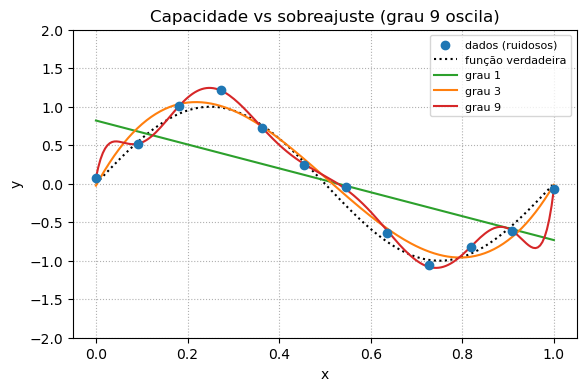

In [8]:
# Dados sintéticos: função suave (seno) + ruído gaussiano.
xs = np.linspace(0, 1, 12)               # 12 pontos de x
y_true = np.sin(2 * np.pi * xs)          # a função "verdadeira" sem ruído
# np.random.randn gera ruído normal; somamos uma versão pequena (0.15) à função.
ys = y_true + 0.15 * np.random.randn(len(xs))
xx_fine = np.linspace(0, 1, 200)         # x's finos para desenhar as curvas ajustadas

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(xs, ys, color="tab:blue", zorder=3, label="dados (ruidosos)")
ax.plot(xx_fine, np.sin(2 * np.pi * xx_fine), "k:", label="função verdadeira")

# Ajustamos polinômios de três graus e desenhamos cada um separadamente.
# Em vez de um laço enxuto, escrevemos as três chamadas explícitas (clareza > concisão):
# para cada grau montamos a Vandermonde dos dados, resolvemos com lstsq (estável)
# e avaliamos o polinômio nos x's finos (Vandermonde de xx_fine) @ beta.

# Grau 1 (reta): baixa capacidade, não acompanha a curva.
beta_g1 = np.linalg.lstsq(np.vander(xs, 2, increasing=True), ys, rcond=None)[0]
ax.plot(xx_fine, np.vander(xx_fine, 2, increasing=True) @ beta_g1,
        color="tab:green", label="grau 1")

# Grau 3: capacidade adequada, segue bem a tendência.
beta_g3 = np.linalg.lstsq(np.vander(xs, 4, increasing=True), ys, rcond=None)[0]
ax.plot(xx_fine, np.vander(xx_fine, 4, increasing=True) @ beta_g3,
        color="tab:orange", label="grau 3")

# Grau 9: capacidade alta demais, ajusta o ruído e oscila (sobreajuste).
beta_g9 = np.linalg.lstsq(np.vander(xs, 10, increasing=True), ys, rcond=None)[0]
ax.plot(xx_fine, np.vander(xx_fine, 10, increasing=True) @ beta_g9,
        color="tab:red", label="grau 9")

ax.set_ylim(-2, 2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.grid(True, ls=":")
ax.set_title("Capacidade vs sobreajuste (grau 9 oscila)")
plt.show()

## 8. Mínimos quadrados ponderados

Se algumas medições são menos confiáveis, usamos pesos $W$:
$A^TW^2A\widehat{\boldsymbol\beta}=A^TW^2\mathbf{b}$. Damos peso baixo a um ponto suspeito.

sem peso : [-0.94  1.98]
com peso : [0.045 0.995] (menos puxado pelo outlier)


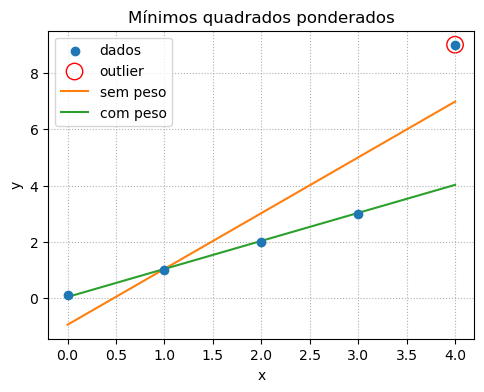

In [9]:
# Reta com um ponto pouco confiável (outlier): comparar sem e com peso.
xo = np.array([0., 1., 2., 3., 4.])
yo = np.array([0.1, 1.0, 2.0, 3.0, 9.0])      # último ponto (x=4) é um outlier
Ao = np.column_stack([np.ones_like(xo), xo])  # matriz de projeto [1, x]

# Ajuste comum (todos os pontos com o mesmo peso): o outlier "puxa" a reta.
beta_sem = np.linalg.lstsq(Ao, yo, rcond=None)[0]

# Ajuste ponderado: damos peso baixo ao ponto suspeito para ele influenciar menos.
w = np.array([1, 1, 1, 1, 0.1])               # peso 0.1 só no outlier
W = np.diag(w)                                # np.diag transforma o vetor w numa matriz diagonal

# Equações normais ponderadas: A^T W^2 A beta = A^T W^2 b.
# Como W é diagonal, W**2 eleva cada peso ao quadrado (NÃO é multiplicação matricial,
# é o quadrado elemento a elemento da diagonal). Resolvemos com solve, como antes.
beta_com = np.linalg.solve(Ao.T @ W**2 @ Ao, Ao.T @ W**2 @ yo)
print("sem peso :", np.round(beta_sem, 3))
print("com peso :", np.round(beta_com, 3), "(menos puxado pelo outlier)")

# Gráfico: dados, o outlier destacado, e as duas retas.
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(xo, yo, color="tab:blue", zorder=3, label="dados")
# Marcamos o outlier com um círculo vazado vermelho por cima do ponto:
ax.scatter([4], [9], facecolors="none", edgecolors="red", s=140, label="outlier")
xxo = np.linspace(0, 4, 50)
ax.plot(xxo, beta_sem[0] + beta_sem[1] * xxo, "tab:orange", label="sem peso")
ax.plot(xxo, beta_com[0] + beta_com[1] * xxo, "tab:green", label="com peso")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, ls=":")
ax.set_title("Mínimos quadrados ponderados")
plt.show()

## 9. Lei de potência por linearização (Exemplo 3)

$y=Cx^\alpha \Rightarrow \ln y=\ln C+\alpha\ln x$: regressão linear em escala log. Recuperamos
$C=e^{\beta_0}$, $\alpha=\beta_1$. *Cuidado:* minimizar erro em $\ln y$ ≠ minimizar em $y$.

C estimado = 1.901 (verdadeiro 2.0) | alpha = 1.521 (verdadeiro 1.5)


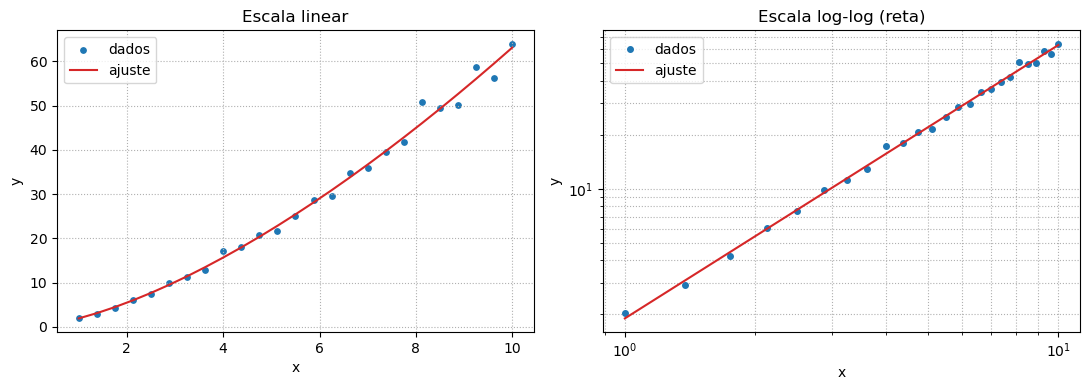

In [10]:
# Dados sintéticos de uma lei de potência y = C x^alpha (com ruído multiplicativo).
C_true, alpha_true = 2.0, 1.5
xp = np.linspace(1, 10, 25)
# Ruído multiplicativo: exp(0.05*ruído) ~ fatores perto de 1, que mexem em y em %.
yp = C_true * xp**alpha_true * np.exp(0.05 * np.random.randn(len(xp)))

# Truque da linearização: aplicar ln em y = C x^alpha dá ln y = ln C + alpha*ln x,
# que é uma RETA nas variáveis X = ln x e Y = ln y. Assim caímos numa regressão linear.
X = np.log(xp)                                  # X = ln x
Y = np.log(yp)                                  # Y = ln y
Alog = np.column_stack([np.ones_like(X), X])    # matriz de projeto [1, ln x]

# lstsq devolve (solução, ...); pegamos a solução com [0] e a desempacotamos em b0, b1.
b0, b1 = np.linalg.lstsq(Alog, Y, rcond=None)[0]
# Voltamos do espaço log para os parâmetros originais: C = e^{b0} e alpha = b1.
C_fit, alpha_fit = np.exp(b0), b1
print(f"C estimado = {C_fit:.3f} (verdadeiro {C_true}) | alpha = {alpha_fit:.3f} (verdadeiro {alpha_true})")

# Dois gráficos lado a lado: escala normal e escala log-log (onde a lei vira reta).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Esquerda: escala linear comum.
ax1.scatter(xp, yp, s=15, label="dados")
ax1.plot(xp, C_fit * xp**alpha_fit, "tab:red", label="ajuste")
ax1.set_title("Escala linear")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True, ls=":")

# Direita: ax.loglog usa escala logarítmica nos DOIS eixos; nela a lei de potência
# aparece como uma reta de inclinação alpha. which="both" mostra as linhas de grade
# principais e secundárias da escala log.
ax2.loglog(xp, yp, "o", ms=4, label="dados")
ax2.loglog(xp, C_fit * xp**alpha_fit, "tab:red", label="ajuste")
ax2.set_title("Escala log-log (reta)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid(True, ls=":", which="both")

plt.tight_layout()
plt.show()

## Síntese da aula

- Regressão linear vira o sistema $A\boldsymbol\beta\approx\mathbf{b}$; mínimos quadrados projeta
  $\mathbf{b}$ em $\operatorname{Col}(A)$, com resíduo ortogonal ($A^T\mathbf{e}=0$) e
  **equações normais** $A^TA\widehat{\boldsymbol\beta}=A^T\mathbf{b}$.
- A **pseudoinversa/SVD** $\widehat{\boldsymbol\beta}=A^+\mathbf{b}$ é mais estável e geral; todos
  os métodos coincidem em posto completo.
- **Equações normais** elevam o condicionamento ao quadrado: prefira `lstsq`/SVD e **normalize**
  os dados (Vandermonde).

## Limitações a discutir

- MQ ($\ell_2$) é **sensível a outliers** (mitigável com pesos ou $\ell_1$).
- $\kappa(A^TA)=\kappa(A)^2$: equações normais podem ser instáveis.
- Grau alto = mais capacidade, **não** melhor modelo (sobreajuste → Aula 10).
- Linearizar (log) **muda a estrutura do erro**.
- $\sigma$ pequenos em $A^+$ amplificam ruído (direções pouco observáveis).

## Experimentos sugeridos

1. Refaça os Exercícios 1 (reta) e 6 (quadrática) com os pontos das notas.
2. Adicione/remova o outlier e compare $\ell_2$ vs ponderado.
3. Varie o grau do polinômio e observe o resíduo e o condicionamento.
4. Exercício 9: $\sigma=(100,10,1,10^{-3})$ — qual direção da solução é mais sensível ao ruído?

*Próxima aula (Aula 10): **regularização** (Ridge e Lasso) para controlar o sobreajuste e lidar
com mal-condicionamento.*